In [2]:
# 1. 파이썬 코드에서 Matplotlib 폰트 설정
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from datetime import timedelta
from itertools import combinations
from collections import Counter

# 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정이 완료되었습니다.")

# 3. 데이터 로드 및 통합 (모든 문제 풀이의 시작점)
try:
    orders_df = pd.read_csv('../data/orders.csv')
    payments_df = pd.read_csv('../data/payments.csv')
    products_df = pd.read_csv('../data/products.csv')
    shipping_df = pd.read_csv('../data/shipping.csv')
    customers_df = pd.read_csv('../data/customers.csv')

    # 모든 데이터프레임 병합
    df = pd.merge(orders_df, payments_df, on='order_id', how='left')
    df = pd.merge(df, products_df, on='product_id', how='left')
    df = pd.merge(df, customers_df, on='customer_id', how='left')
    df = pd.merge(df, shipping_df, on='order_id', how='left')

    # 데이터 전처리
    date_cols = ['order_date', 'payment_date', 'join_date', 'shipping_start_date', 'shipping_end_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce') # pandas의 to_datetime 검색해서 사용법 잘 봐 두고
    df['total_sales'] = df['quantity'] * df['price']
    
    print("데이터 로드 및 통합이 완료되었습니다.")

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")


한글 폰트 설정이 완료되었습니다.
데이터 로드 및 통합이 완료되었습니다.


In [3]:
# 문제 8: 고객이 주로 활동하는 상위 15개 도시를 파악하고, 도시별 고객 수와 총매출액을 비교하세요.
# 시각화: 바 차트 (이중 축 : x, y, 오른쪽(총 매출액))

# 비즈니스 목적: 지역 기반 마케팅 전략을 수립하고, 특정 도시에 오프라인 매장을 열거나 지역 광고를 집행할 때의 의사결정 근거로 활용합니다.

###### 출력 결과를 보고 코딩하세요
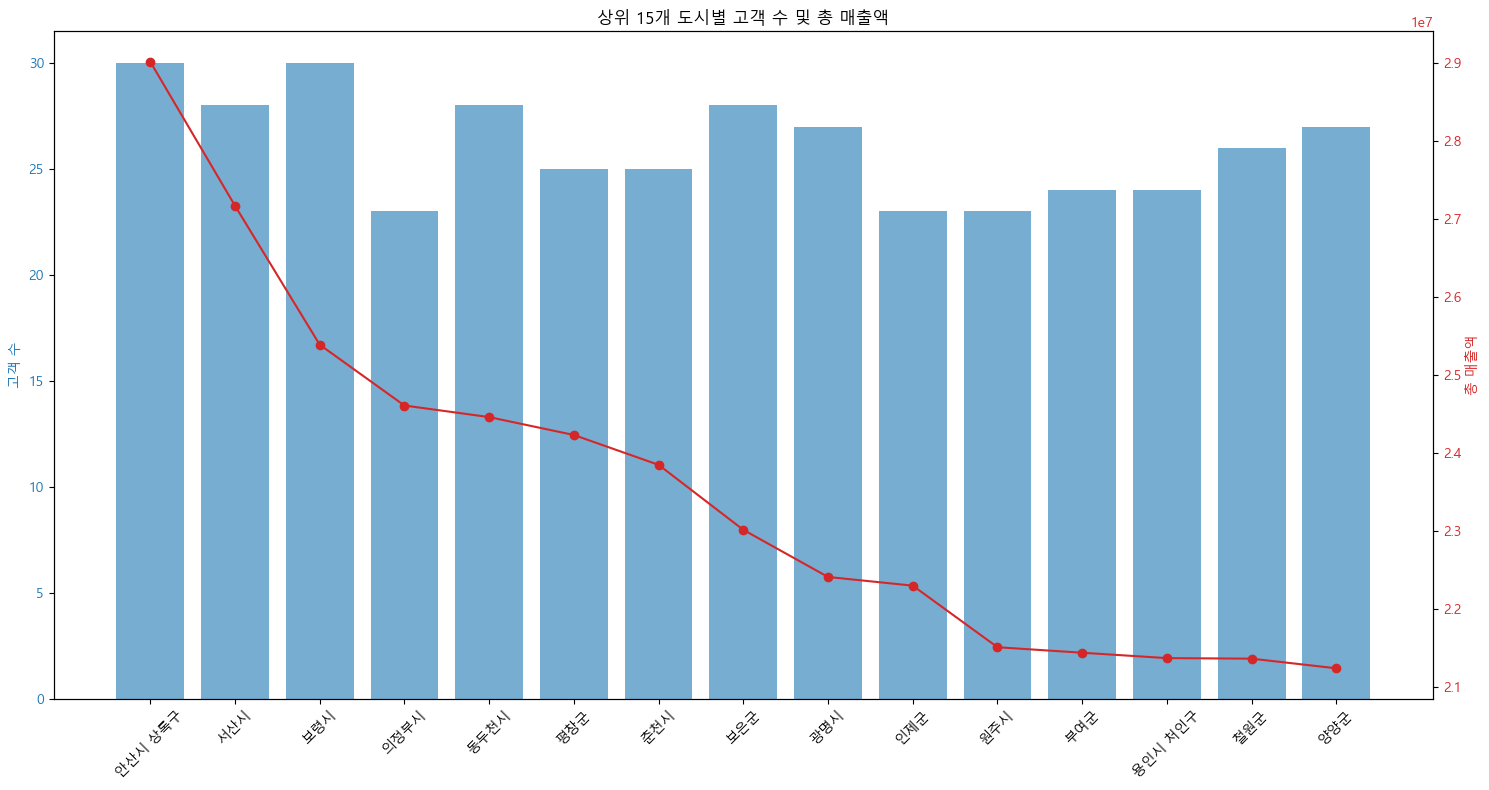

In [ ]:
df.columns

Index(['order_id', 'customer_id', 'product_id', 'order_date', 'quantity',
       'payment_id', 'payment_method', 'payment_status', 'payment_date',
       'product_name', 'category', 'price', 'stock', 'name', 'gender', 'age',
       'join_date', 'city', 'shipping_id', 'shipping_company',
       'shipping_status', 'shipping_start_date', 'shipping_end_date',
       'total_sales'],
      dtype='object')

In [11]:
# 고객이 주로 활동하는 상위 15개 도시를 파악하고, 도시별 고객 수와 총매출액을 비교
# 시각화: 바 차트 (이중 축 : x, y, 오른쪽(총 매출액))
# 필요한 컬럼 확인 : [ 'customer_id', 'city', 'total_sales']
# 도시별로 그룹핑하고 그때의 고객수 coutn와 총 구매액을 sum
df_quest28= (
  df[['customer_id', 'city', 'total_sales']].copy()
  .groupby('city')
  .agg(
    total_revenue = ('total_sales', 'sum'),    # 도시별 총 매출
    cust_counts  = ('customer_id', 'nunique')    # 도시별 고객수(중복제거)
  )
  .reset_index()
  .sort_values('total_revenue', ascending=False)   # 고객수 기준 내림차순 정렬
  .head(15)  # 상위 15개 도시만 선택    
)
print(df_quest28)

       city  total_revenue  cust_counts
47  안산시 상록구       29023200           30
31      서산시       27176000           28
23      보령시       25393100           30
70     의정부시       24612900           23
21     동두천시       24464300           28
90      평창군       24234900           25
85      춘천시       23852100           25
24      보은군       23018300           28
10      광명시       22413700           27
72      인제군       22302400           23
67      원주시       21512700           23
25      부여군       21441900           24
66  용인시 처인구       21372900           24
79      철원군       21365900           26
53      양양군       21242200           27


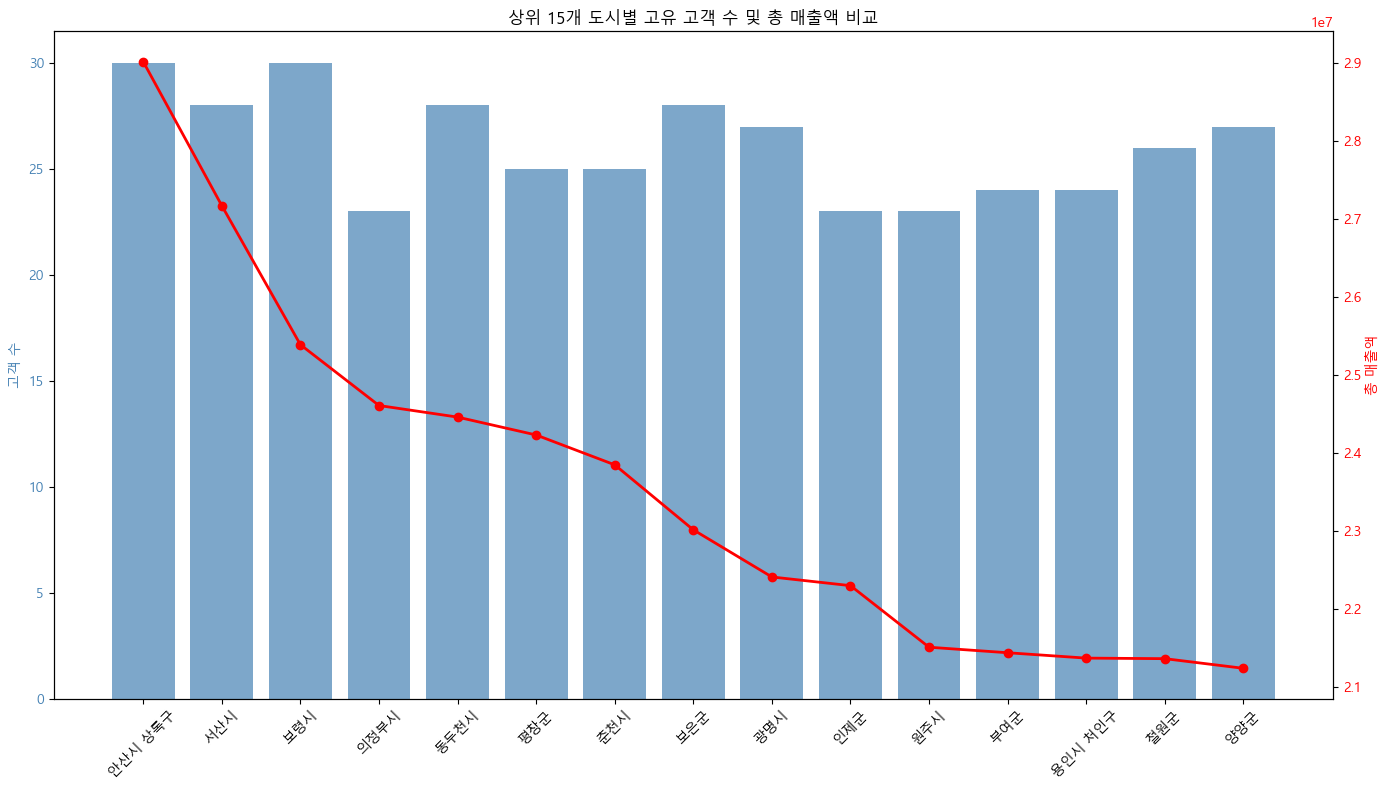

In [14]:
# 시각화: 이중 축 바 차트
fig, ax1 = plt.subplots(figsize=(14, 8))

# 왼쪽 축: 고객 수 (막대 그래프)
color1 = 'steelblue'
# ax1.set_xlabel('도시', fontsize=12)
ax1.set_ylabel('고객 수', color=color1)
bars = ax1.bar(
    df_quest28['city'], 
    df_quest28['cust_counts'], 
    color=color1,
    alpha=0.7, 
    label='고객 수'
)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.tick_params(axis='x', rotation=45)

# 오른쪽 축: 총 매출액 (선 그래프)
ax2 = ax1.twinx()
color2 = 'red'
ax2.set_ylabel('총 매출액', color=color2)
line = ax2.plot(
      df_quest28['city'], 
      df_quest28['total_revenue'], 
      color=color2, 
      marker='o', 
      linewidth=2, 
      label='총 매출액')
ax2.tick_params(axis='y', labelcolor=color2)

# 제목 및 레이아웃 조정
plt.title('상위 15개 도시별 고유 고객 수 및 총 매출액 비교')
fig.tight_layout()

plt.show()